# Adapter :: Textual Inversion

-----
- Conda env : [cv_playgrounds](../README.md#setup-a-conda-environment)
-----

- Ref: 
    - https://huggingface.co/docs/diffusers/v0.34.0/en/using-diffusers/textual_inversion_inference

## 0. Configure device

In [1]:
#@title
import torch

if torch.backends.mps.is_available():
    t_device = torch.device("mps")
    s_device = "mps"
    print(f"Current memory allocated on MPS: {torch.mps.current_allocated_memory()} bytes")
    print(f"Driver memory allocated on MPS: {torch.mps.driver_allocated_memory()} bytes")
    if torch.mps.driver_allocated_memory() - torch.mps.current_allocated_memory()< 1e4:
        print("Not enough mps memory, convert to cpu mode")
        t_device = torch.device("cpu")
        s_device = "cpu"
elif torch.cuda.is_available():
    t_device = torch.device("cuda")
    s_device = "cuda"
else:
    t_device = torch.device("cpu")
    s_device = "cpu"
print(t_device)

cuda


In [2]:
import torch
from diffusers import AutoPipelineForText2Image

pipeline = AutoPipelineForText2Image.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/50 [00:00<?, ?it/s]

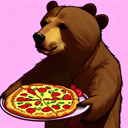

In [5]:
pipeline.load_textual_inversion("sd-concepts-library/gta5-artwork")
prompt = "A cute brown bear eating a slice of pizza, stunning color scheme, masterpiece, illustration, <gta5-artwork> style"
pipeline(prompt).images[0].resize((128, 128))

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

easynegative.safetensors:   0%|          | 0.00/24.7k [00:00<?, ?B/s]

  0%|          | 0/50 [00:00<?, ?it/s]

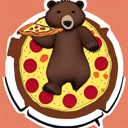

In [4]:
import torch
from diffusers import AutoPipelineForText2Image

pipeline = AutoPipelineForText2Image.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")
pipeline.load_textual_inversion(
    "EvilEngine/easynegative",
    weight_name="easynegative.safetensors",
    token="easynegative"
)
prompt = "A cute brown bear eating a slice of pizza, stunning color scheme, masterpiece, illustration"
negative_prompt = "easynegative"
pipeline(prompt, negative_prompt).images[0].resize((128, 128))